In [1]:
import pandas as pd

data = pd.read_csv('/content/CICEVSE2024_12classes_sample.csv')

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

print("\nFirst 5 rows:")
display(data.head())

Dataset shape: (35941, 86)

Columns:
['expiration_id', 'src_ip', 'src_mac', 'src_oui', 'src_port', 'dst_ip', 'dst_mac', 'dst_oui', 'dst_port', 'protocol', 'ip_version', 'vlan_id', 'tunnel_id', 'bidirectional_first_seen_ms', 'bidirectional_last_seen_ms', 'bidirectional_duration_ms', 'bidirectional_packets', 'bidirectional_bytes', 'src2dst_first_seen_ms', 'src2dst_last_seen_ms', 'src2dst_duration_ms', 'src2dst_packets', 'src2dst_bytes', 'dst2src_first_seen_ms', 'dst2src_last_seen_ms', 'dst2src_duration_ms', 'dst2src_packets', 'dst2src_bytes', 'bidirectional_min_ps', 'bidirectional_mean_ps', 'bidirectional_stddev_ps', 'bidirectional_max_ps', 'src2dst_min_ps', 'src2dst_mean_ps', 'src2dst_stddev_ps', 'src2dst_max_ps', 'dst2src_min_ps', 'dst2src_mean_ps', 'dst2src_stddev_ps', 'dst2src_max_ps', 'bidirectional_min_piat_ms', 'bidirectional_mean_piat_ms', 'bidirectional_stddev_piat_ms', 'bidirectional_max_piat_ms', 'src2dst_min_piat_ms', 'src2dst_mean_piat_ms', 'src2dst_stddev_piat_ms', 'src2dst

,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,...,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,Label
0,0.0,0.396825,0.500000,0.714286,0.135668,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
1,0.0,0.476190,0.500000,0.714286,0.347005,0.453333,0.176471,0.111111,0.001221,0.020408,...,0.230769,1.000000,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
2,0.0,0.317460,0.833333,0.857143,0.703655,0.346667,0.705882,0.777778,0.008286,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1
3,0.0,0.539683,0.500000,0.714286,0.942000,0.400000,0.705882,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,10
4,0.0,0.396825,0.500000,0.714286,0.152590,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5


In [2]:
print(data.info())

print("\nClass distribution:")
print(data['Label'].value_counts())

print("\nClass distribution (%):")
print(data['Label'].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35941 entries, 0 to 35940
Data columns (total 86 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   expiration_id                 35941 non-null  float64
 1   src_ip                        35941 non-null  float64
 2   src_mac                       35941 non-null  float64
 3   src_oui                       35941 non-null  float64
 4   src_port                      35941 non-null  float64
 5   dst_ip                        35941 non-null  float64
 6   dst_mac                       35941 non-null  float64
 7   dst_oui                       35941 non-null  float64
 8   dst_port                      35941 non-null  float64
 9   protocol                      35941 non-null  float64
 10  ip_version                    35941 non-null  float64
 11  vlan_id                       35941 non-null  float64
 12  tunnel_id                     35941 non-null  float64
 13  b

## Label encoding check
Make this notebook safe to run regardless of whether `Label` is already integer-encoded (as it is in this pre-sampled CICIDS2017 file) or still text categories. The raw-XGBoost cells later on cast labels to `int32`, so encoding this once up front — and deriving `N_CLASSES`/`ALL_CLASSES` from the data instead of hardcoding `7` everywhere — avoids a crash and keeps every downstream cell consistent.

In [3]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("Label dtype:", data['Label'].dtype)

if not pd.api.types.is_numeric_dtype(data['Label']):
    label_encoder = LabelEncoder()
    data['Label'] = label_encoder.fit_transform(data['Label'])

    print("\nLabels were text -- encoded to integers:")
    for i, cls in enumerate(label_encoder.classes_):
        print(f"  {i} -> {cls}")
else:
    label_encoder = None
    print("\nLabels are already numeric -- no encoding needed.")

N_CLASSES = int(data['Label'].nunique())
ALL_CLASSES = np.sort(data['Label'].unique())

print("\nNumber of classes:", N_CLASSES)
print("Class values:", ALL_CLASSES)

Label dtype: int64

Labels are already numeric -- no encoding needed.

Number of classes: 12
Class values: [ 0  1  2  3  4  5  6  7  8  9 10 11]


In [4]:
from sklearn.model_selection import train_test_split

# Features and target
X = data.drop(columns=['Label'])
y = data['Label']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

X_train shape: (28752, 85)
X_test shape: (7189, 85)
y_train shape: (28752,)
y_test shape: (7189,)

Training class distribution:
Label
0       66
1     3791
2     2737
3     4645
4       72
5     2488
6      835
7     6157
8     2952
9     1262
10    1518
11    2229
Name: count, dtype: int64

Testing class distribution:
Label
0       16
1      948
2      684
3     1162
4       18
5      622
6      209
7     1539
8      738
9      315
10     380
11     558
Name: count, dtype: int64


## Centralized baseline models
One model per algorithm trained on the full training set. These are the reference points that the federated (IID / Non-IID) results are compared against.


3-Fold Macro F1 Scores: [0.98258022 0.97865999 0.99563359]
Mean CV Macro F1: 0.9856246016595196
CV Time: 9.120291948318481 seconds

Training time: 1.0761349201202393 seconds

Prediction time: 0.0057103633880615234 seconds
Prediction time per sample: 0.000794319569907014 ms

DECISION TREE RESULTS
Accuracy: 0.9991653915704548
Macro Precision: 0.9940175771976131
Macro Recall: 0.9897730437204122
Macro F1: 0.9918330251642798
Weighted F1: 0.9991594771708413

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00       948
           2       1.00      1.00      1.00       684
           3       1.00      1.00      1.00      1162
           4       0.94      0.89      0.91        18
           5       1.00      1.00      1.00       622
           6       1.00      1.00      1.00       209
           7       1.00      1.00      1.00      1539
           8       1.00      1.0

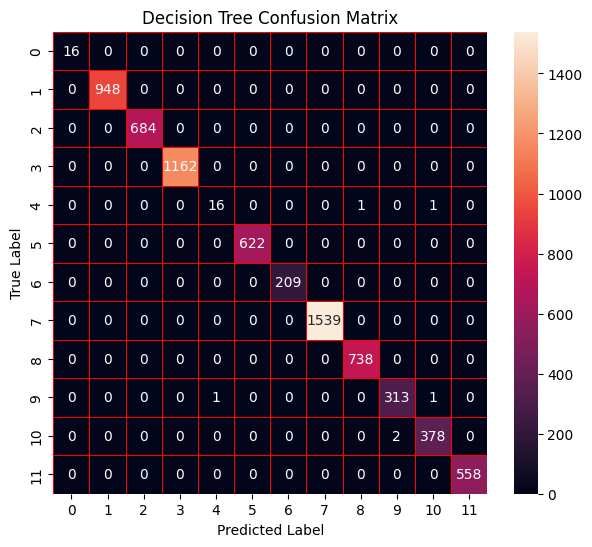


Tree depth: 18
Number of leaves: 84
CPU times: user 1.63 s, sys: 88.2 ms, total: 1.72 s
Wall time: 11.9 s


In [5]:
%%time

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. Decision Tree
# ============================================================

dt = DecisionTreeClassifier(
    random_state=0,
    class_weight='balanced'
)


# ============================================================
# 2. 3-Fold Stratified Cross-Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

start = time.time()

cv_scores = cross_val_score(
    dt,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

cv_time = time.time() - start


print("\n3-Fold Macro F1 Scores:", cv_scores)
print("Mean CV Macro F1:", np.mean(cv_scores))
print("CV Time:", cv_time, "seconds")


# ============================================================
# 3. Train on complete training set
# ============================================================

start = time.time()

dt.fit(X_train, y_train)

training_time = time.time() - start

print("\nTraining time:", training_time, "seconds")


# ============================================================
# 4. Test prediction
# ============================================================

start = time.time()

y_pred = dt.predict(X_test)

prediction_time = time.time() - start

print("\nPrediction time:", prediction_time, "seconds")
print(
    "Prediction time per sample:",
    prediction_time / len(X_test) * 1000,
    "ms"
)


# ============================================================
# 5. Test evaluation
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n==============================")
print("DECISION TREE RESULTS")
print("==============================")
print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


# ============================================================
# 6. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', linewidths=0.5, linecolor='red')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree Confusion Matrix")
plt.show()

print("\nTree depth:", dt.get_depth())
print("Number of leaves:", dt.get_n_leaves())

centralized_dt_results = {
    "Model": "Decision Tree",
    "Setting": "Centralized",
    "Accuracy": accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1
}

3-Fold Macro F1 Scores: [0.98673869 0.98557369 0.98965456]
Mean CV Macro F1: 0.9873223130041658

Training time: 5.395986795425415 seconds

RANDOM FOREST RESULTS (100 trees)
Accuracy: 0.9987480873556823
Macro Precision: 0.9938919837610554
Macro Recall: 0.9980665250614317
Macro F1: 0.9959156043911163
Weighted F1: 0.9987499920934025

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00       948
           2       1.00      1.00      1.00       684
           3       1.00      1.00      1.00      1162
           4       0.95      1.00      0.97        18
           5       1.00      1.00      1.00       622
           6       1.00      1.00      1.00       209
           7       1.00      1.00      1.00      1539
           8       1.00      1.00      1.00       738
           9       0.99      1.00      0.99       315
          10       1.00      0.99      0.99      

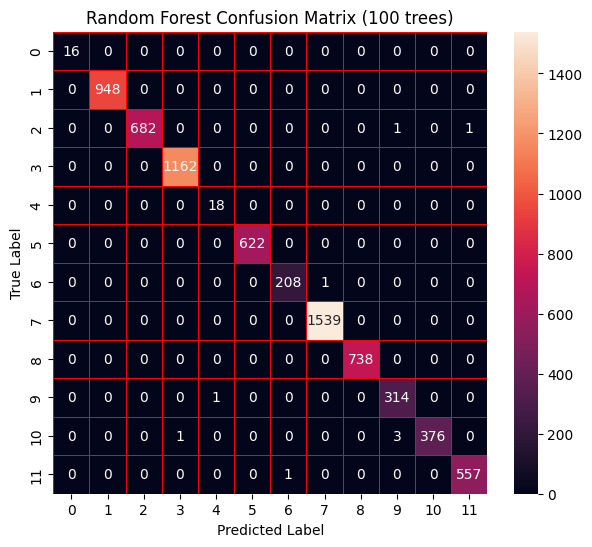

CPU times: user 7.11 s, sys: 180 ms, total: 7.29 s
Wall time: 21.3 s


In [6]:
%%time

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. Random Forest (100 trees)
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=0,
    class_weight='balanced',
    n_jobs=-1
)


# ============================================================
# 2. 3-Fold Stratified Cross-Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

rf_cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

print("3-Fold Macro F1 Scores:", rf_cv_scores)
print("Mean CV Macro F1:", np.mean(rf_cv_scores))


# ============================================================
# 3. Train Random Forest
# ============================================================

start = time.time()
rf.fit(X_train, y_train)
training_time = time.time() - start

print("\nTraining time:", training_time, "seconds")


# ============================================================
# 4. Test prediction and evaluation
# ============================================================

start = time.time()
y_pred = rf.predict(X_test)
prediction_time = time.time() - start

accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n==============================")
print("RANDOM FOREST RESULTS (100 trees)")
print("==============================")
print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', linewidths=0.5, linecolor='red')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix (100 trees)")
plt.show()

centralized_rf_results = {
    "Model": "Random Forest",
    "Setting": "Centralized (100 trees)",
    "Accuracy": accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1
}

### Fair-comparison centralized Random Forest (300 trees)
The federated Random Forest below pools 3 clients x 100 trees = 300 trees into one ensemble. Comparing that directly against the 100-tree centralized model above isn't apples-to-apples -- a bigger forest tends to do better regardless of federation. This 300-tree centralized run matches the federated model's total tree budget so any gap between them reflects the effect of partitioning the data across clients, not just having more trees.

In [7]:
%%time

rf_300 = RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    class_weight='balanced',
    n_jobs=-1
)

start = time.time()
rf_300.fit(X_train, y_train)
training_time_300 = time.time() - start

y_pred_300 = rf_300.predict(X_test)

accuracy_300 = accuracy_score(y_test, y_pred_300)
macro_precision_300 = precision_score(y_test, y_pred_300, average='macro', zero_division=0)
macro_recall_300 = recall_score(y_test, y_pred_300, average='macro', zero_division=0)
macro_f1_300 = f1_score(y_test, y_pred_300, average='macro', zero_division=0)
weighted_f1_300 = f1_score(y_test, y_pred_300, average='weighted', zero_division=0)

print("==============================")
print("RANDOM FOREST RESULTS (300 trees, fair-comparison baseline)")
print("==============================")
print("Training time:", training_time_300, "seconds")
print("Accuracy:", accuracy_300)
print("Macro F1:", macro_f1_300)
print("Weighted F1:", weighted_f1_300)

centralized_rf_300_results = {
    "Model": "Random Forest",
    "Setting": "Centralized (300 trees)",
    "Accuracy": accuracy_300,
    "Macro Precision": macro_precision_300,
    "Macro Recall": macro_recall_300,
    "Macro F1": macro_f1_300,
    "Weighted F1": weighted_f1_300
}

RANDOM FOREST RESULTS (300 trees, fair-comparison baseline)
Training time: 11.278769969940186 seconds
Accuracy: 0.9987480873556823
Macro F1: 0.9958598065132942
Weighted F1: 0.9987509144293419
CPU times: user 18.9 s, sys: 114 ms, total: 19 s
Wall time: 11.5 s


In [8]:
!pip install xgboost -q

3-Fold Macro F1 Scores: [0.98275537 0.98958815 0.99260382]
Mean CV Macro F1: 0.9883157789057324

Training time: 11.220567464828491 seconds

XGBOOST RESULTS
Accuracy: 0.9995826957852274
Macro Precision: 0.9952625102759032
Macro Recall: 0.9992601453127768
Macro F1: 0.997201158775304
Weighted F1: 0.9995844131191907

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00       948
           2       1.00      1.00      1.00       684
           3       1.00      1.00      1.00      1162
           4       0.95      1.00      0.97        18
           5       1.00      1.00      1.00       622
           6       1.00      1.00      1.00       209
           7       1.00      1.00      1.00      1539
           8       1.00      1.00      1.00       738
           9       1.00      1.00      1.00       315
          10       1.00      1.00      1.00       380
          11 

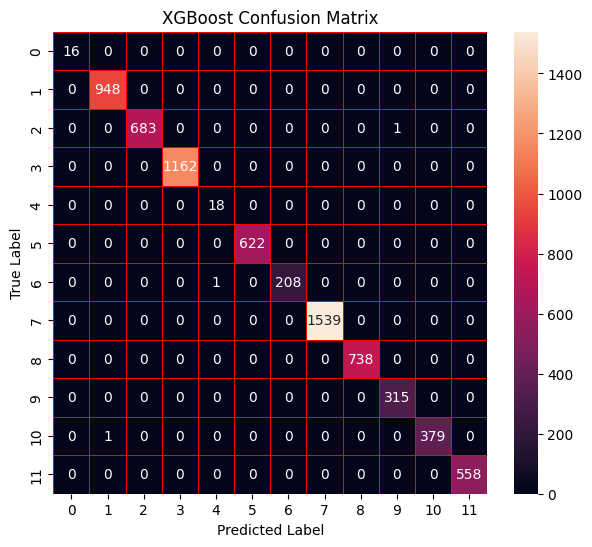

CPU times: user 1min 12s, sys: 239 ms, total: 1min 13s
Wall time: 58.1 s


In [9]:
%%time

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. XGBoost
# ============================================================

xgb_clf = XGBClassifier(
    objective='multi:softmax',
    num_class=N_CLASSES,
    n_estimators=100,
    random_state=0,
    eval_metric='mlogloss'
)


# ============================================================
# 2. 3-Fold Stratified Cross-Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

xgb_cv_scores = cross_val_score(
    xgb_clf,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print("3-Fold Macro F1 Scores:", xgb_cv_scores)
print("Mean CV Macro F1:", np.mean(xgb_cv_scores))


# ============================================================
# 3. Train and evaluate
# ============================================================

start = time.time()
xgb_clf.fit(X_train, y_train)
training_time = time.time() - start

print("\nTraining time:", training_time, "seconds")

y_pred = xgb_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n==============================")
print("XGBOOST RESULTS")
print("==============================")
print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', linewidths=0.5, linecolor='red')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix")
plt.show()

centralized_xgb_results = {
    "Model": "XGBoost",
    "Setting": "Centralized",
    "Accuracy": accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1
}

In [10]:
!pip install lightgbm -q

3-Fold Macro F1 Scores: [0.27518134 0.98577662 0.22233896]
Mean CV Macro F1: 0.494432307287731

Training time: 8.916746139526367 seconds

LIGHTGBM RESULTS
Accuracy: 0.9988871887606064
Macro Precision: 0.9943267841901763
Macro Recall: 0.989296157059315
Macro F1: 0.9914613120851054
Weighted F1: 0.9988787861164915

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      1.00      1.00       948
           2       1.00      1.00      1.00       684
           3       1.00      1.00      1.00      1162
           4       1.00      0.89      0.94        18
           5       1.00      1.00      1.00       622
           6       1.00      1.00      1.00       209
           7       1.00      1.00      1.00      1539
           8       1.00      1.00      1.00       738
           9       1.00      0.98      0.99       315
          10       1.00      1.00      1.00       380
          11  

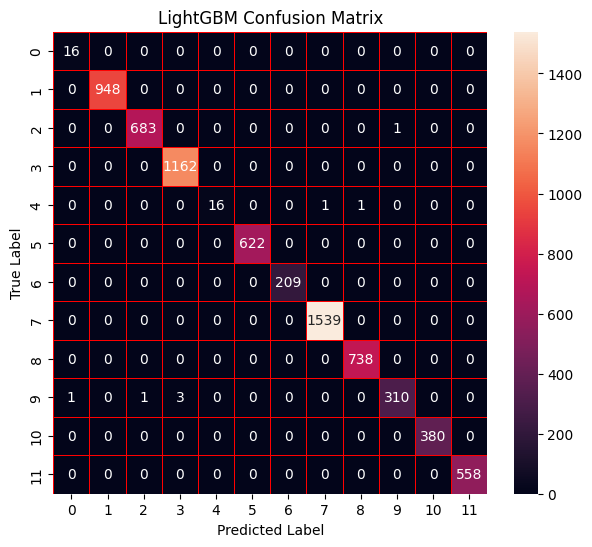

CPU times: user 33 s, sys: 317 ms, total: 33.3 s
Wall time: 45.3 s


In [11]:
%%time

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

lgbm_clf = LGBMClassifier(
    objective='multiclass',
    num_class=N_CLASSES,
    n_estimators=100,
    random_state=0,
    verbosity=-1
)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

lgbm_cv_scores = cross_val_score(
    lgbm_clf,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print("3-Fold Macro F1 Scores:", lgbm_cv_scores)
print("Mean CV Macro F1:", np.mean(lgbm_cv_scores))

start = time.time()
lgbm_clf.fit(X_train, y_train)
training_time = time.time() - start

print("\nTraining time:", training_time, "seconds")

y_pred = lgbm_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n==============================")
print("LIGHTGBM RESULTS")
print("==============================")
print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', linewidths=0.5, linecolor='red')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LightGBM Confusion Matrix")
plt.show()

centralized_lgbm_results = {
    "Model": "LightGBM",
    "Setting": "Centralized",
    "Accuracy": accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1
}

## Federated learning utilities
These helpers are shared by every federated experiment below (both IID and Non-IID, for all four models).

**Why they exist:** the straightforward way to "federate" a tree ensemble is to pool trees (Random Forest) or soft-vote probabilities (Decision Tree / XGBoost / LightGBM) from independently trained per-client models. That's the ensemble-style approach used throughout this notebook -- it's a one-shot aggregation, not iterative round-based FedAvg (which doesn't apply cleanly to trees). Worth stating explicitly in the methodology section of the writeup.

**The bug this fixes:** naively assuming every client's model reports probabilities/classes in the same column order breaks under Non-IID partitioning. CICIDS2017 has very rare classes (e.g. Heartbleed), so a Dirichlet split can easily leave one client with zero samples of a class. When that happens:
- Pooling a `RandomForestClassifier`'s `.estimators_` after a `copy.deepcopy` (the naive approach) crashes with a shape-mismatch error, because each client's trees are indexed to *that client's own* `classes_`, not a shared global one.
- `LGBMClassifier.predict_proba()` also indexes columns by that client's own `classes_`, *even when `num_class` is hardcoded* -- so naively averaging raw probability arrays across clients silently scrambles which column means which class.

`pooled_rf_predict_proba` and `soft_voting_proba` below fix both cases by explicitly aligning each client's output columns to the global class list (`ALL_CLASSES`) before combining. This was verified against a synthetic imbalanced dataset before being used here: the naive approach crashed / misaligned columns, this approach didn't.

In [12]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def check_class_coverage(clients, all_classes, label=""):
    """Print which classes (if any) each client is missing."""
    all_classes = list(all_classes)
    any_missing = False

    title = f"Class coverage check ({label})" if label else "Class coverage check"
    print("=" * 60)
    print(title)
    print("=" * 60)

    for client in clients:
        present = sorted(client["y"].unique())
        missing = [c for c in all_classes if c not in present]

        status = "OK" if not missing else f"MISSING {missing}"
        print(f"Client {client['client_id']}: {len(client['y'])} samples -> {status}")

        if missing:
            any_missing = True

    if any_missing:
        print(
            "\nAt least one client is missing one or more classes. The "
            "pooled/soft-voting aggregation below aligns each client's "
            "output to the global class list, so this is handled safely -- "
            "but be aware a client's LOCAL per-client metrics for a class "
            "it never saw will trivially be 0 for that class."
        )
    else:
        print("\nAll clients have samples from every class.")

    return any_missing


def pooled_rf_predict_proba(client_rf_models, X, all_classes):
    """
    Federated Random Forest via tree pooling, robust to clients that are
    missing classes (as can happen under Non-IID partitioning).

    Each client's individual trees index their probability columns to
    THAT CLIENT's `classes_` (not a shared global one), so we can't just
    swap `.estimators_` onto a deep-copied model and call `.predict()` --
    that assumes uniform column order across every tree from every client
    and either crashes (different widths) or silently misaligns
    probabilities (same width, different class sets). Instead, every
    tree's output is explicitly mapped onto the global class list before
    being averaged in.
    """
    all_classes = np.asarray(all_classes)
    class_to_idx = {c: i for i, c in enumerate(all_classes)}
    X_arr = X.values if hasattr(X, "values") else np.asarray(X)
    n_samples = X_arr.shape[0]

    global_proba = np.zeros((n_samples, len(all_classes)))
    total_trees = 0

    for model in client_rf_models:
        col_idx = [class_to_idx[c] for c in model.classes_]
        for tree in model.estimators_:
            tree_proba = tree.predict_proba(X_arr)
            global_proba[:, col_idx] += tree_proba
            total_trees += 1

    global_proba /= total_trees
    return global_proba


def soft_voting_proba(models, X, all_classes):
    """
    Uniform soft-voting federated aggregation for any client models that
    expose `.predict_proba()` and `.classes_` (Decision Tree, LightGBM's
    sklearn API, ...). Same class-alignment fix as `pooled_rf_predict_proba`,
    needed because a client model trained without ever seeing a given
    class reports fewer probability columns than the global class count --
    even when `num_class` is passed explicitly to LightGBM.
    """
    all_classes = np.asarray(all_classes)
    class_to_idx = {c: i for i, c in enumerate(all_classes)}
    n_samples = X.shape[0]

    global_proba = np.zeros((n_samples, len(all_classes)))

    for model in models:
        proba = model.predict_proba(X)
        col_idx = [class_to_idx[c] for c in model.classes_]
        global_proba[:, col_idx] += proba

    global_proba /= len(models)
    return global_proba


def predict_from_proba(global_proba, all_classes):
    all_classes = np.asarray(all_classes)
    return all_classes[np.argmax(global_proba, axis=1)]


# Master results table -- every centralized/federated experiment appends
# one row here so we can answer "which performs best" at the end.
all_results = []


def record_result(model_name, setting, y_true, y_pred, extra=None):
    result = {
        "Model": model_name,
        "Setting": setting,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    if extra:
        result.update(extra)

    all_results.append(result)

    print(
        f"[{model_name} | {setting}] "
        f"Accuracy={result['Accuracy']:.4f}  Macro F1={result['Macro F1']:.4f}"
    )
    return result


# Record the centralized baselines computed above.
for centralized_result in (
    centralized_dt_results,
    centralized_rf_results,
    centralized_rf_300_results,
    centralized_xgb_results,
    centralized_lgbm_results,
):
    all_results.append(centralized_result)

print("\nRecorded", len(all_results), "centralized baseline results.")


Recorded 5 centralized baseline results.


## IID client partitioning
Shared by Random Forest, Decision Tree, XGBoost and LightGBM's federated-IID experiments below. Built with `StratifiedKFold` so each client's local class proportions match the full training set.

In [13]:
#CREATING 3 IID CLIENTS
from sklearn.model_selection import StratifiedKFold

N_CLIENTS = 3
RANDOM_STATE = 42

skf = StratifiedKFold(
    n_splits=N_CLIENTS,
    shuffle=True,
    random_state=RANDOM_STATE
)

clients = []

for client_id, (_, client_idx) in enumerate(
    skf.split(X_train, y_train), start=1
):

    X_client = X_train.iloc[client_idx].copy()
    y_client = y_train.iloc[client_idx].copy()

    clients.append({
        "client_id": client_id,
        "X": X_client,
        "y": y_client
    })

print(f"Number of clients: {len(clients)}")

for client in clients:
    print(
        f"Client {client['client_id']}: "
        f"{client['X'].shape[0]} samples"
    )

Number of clients: 3
Client 1: 9584 samples
Client 2: 9584 samples
Client 3: 9584 samples


In [14]:
for client in clients:
    client_id = client["client_id"]
    y_client = client["y"]

    counts = y_client.value_counts().sort_index()
    percentages = y_client.value_counts(normalize=True).sort_index() * 100

    distribution = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    print(f"\nClient {client_id}")
    print(distribution)

check_class_coverage(clients, ALL_CLASSES, label="IID")


Client 1
       Count  Percentage
Label                   
0         22        0.23
1       1264       13.19
2        912        9.52
3       1548       16.15
4         24        0.25
5        829        8.65
6        278        2.90
7       2053       21.42
8        984       10.27
9        421        4.39
10       506        5.28
11       743        7.75

Client 2
       Count  Percentage
Label                   
0         22        0.23
1       1263       13.18
2        913        9.53
3       1549       16.16
4         24        0.25
5        829        8.65
6        278        2.90
7       2052       21.41
8        984       10.27
9        421        4.39
10       506        5.28
11       743        7.75

Client 3
       Count  Percentage
Label                   
0         22        0.23
1       1264       13.19
2        912        9.52
3       1548       16.15
4         24        0.25
5        830        8.66
6        279        2.91
7       2052       21.41
8        984       1

False

## Random Forest -- Federated IID

In [15]:
from sklearn.ensemble import RandomForestClassifier

local_rf_iid_models = []

for client in clients:

    client_id = client["client_id"]
    X_client = client["X"]
    y_client = client["y"]

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=0,
        class_weight='balanced',
        n_jobs=-1
    )

    model.fit(X_client, y_client)

    local_rf_iid_models.append(model)

    print(
        f"Client {client_id} trained "
        f"({len(X_client)} samples)"
    )

Client 1 trained (9584 samples)
Client 2 trained (9584 samples)
Client 3 trained (9584 samples)


In [16]:
local_rf_iid_results = []

for i, model in enumerate(local_rf_iid_models, start=1):

    y_pred_local = model.predict(X_test)

    results = {
        "Client": i,
        "Accuracy": accuracy_score(y_test, y_pred_local),
        "Macro Precision": precision_score(y_test, y_pred_local, average='macro', zero_division=0),
        "Macro Recall": recall_score(y_test, y_pred_local, average='macro', zero_division=0),
        "Macro F1": f1_score(y_test, y_pred_local, average='macro', zero_division=0)
    }

    local_rf_iid_results.append(results)

local_rf_iid_results_df = pd.DataFrame(local_rf_iid_results)
print(local_rf_iid_results_df)

   Client  Accuracy  Macro Precision  Macro Recall  Macro F1
0       1  0.998331         0.997512      0.992928  0.995142
1       2  0.997496         0.992119      0.987741  0.989867
2       3  0.998053         0.975306      0.973798  0.974419


In [17]:
# Federated aggregation via class-aligned tree pooling (see the
# `pooled_rf_predict_proba` utility cell for why this replaces the naive
# deepcopy + `.estimators_` swap).

global_proba = pooled_rf_predict_proba(local_rf_iid_models, X_test, ALL_CLASSES)
y_pred_federated_rf_iid = predict_from_proba(global_proba, ALL_CLASSES)

print("Federated RF (IID) created from", sum(len(m.estimators_) for m in local_rf_iid_models), "pooled trees")

record_result(
    "Random Forest",
    "Federated-IID",
    y_test,
    y_pred_federated_rf_iid,
    extra={"Total Trees": sum(len(m.estimators_) for m in local_rf_iid_models)}
)

Federated RF (IID) created from 300 pooled trees
[Random Forest | Federated-IID] Accuracy=0.9986  Macro F1=0.9935


{'Model': 'Random Forest',
 'Setting': 'Federated-IID',
 'Accuracy': 0.9986089859507581,
 'Macro Precision': 0.9936133662846935,
 'Macro Recall': 0.9933394295448624,
 'Macro F1': 0.9934706900654109,
 'Weighted F1': 0.9986084070961956,
 'Total Trees': 300}

## Decision Tree -- Federated IID
A single Decision Tree has no natural way to "pool" like a forest does, so it's federated the same way as XGBoost/LightGBM below: train one tree per client, then combine via uniform soft voting.

In [18]:
from sklearn.tree import DecisionTreeClassifier

local_dt_iid_models = []

for client in clients:

    client_id = client["client_id"]
    X_client = client["X"]
    y_client = client["y"]

    model = DecisionTreeClassifier(
        random_state=0,
        class_weight='balanced'
    )

    model.fit(X_client, y_client)

    local_dt_iid_models.append(model)

    print(
        f"Client {client_id} trained "
        f"({len(X_client)} samples)"
    )

Client 1 trained (9584 samples)
Client 2 trained (9584 samples)
Client 3 trained (9584 samples)


In [19]:
local_dt_iid_results = []

for i, model in enumerate(local_dt_iid_models, start=1):

    y_pred_local = model.predict(X_test)

    results = {
        "Client": i,
        "Accuracy": accuracy_score(y_test, y_pred_local),
        "Macro Precision": precision_score(y_test, y_pred_local, average='macro', zero_division=0),
        "Macro Recall": recall_score(y_test, y_pred_local, average='macro', zero_division=0),
        "Macro F1": f1_score(y_test, y_pred_local, average='macro', zero_division=0)
    }

    local_dt_iid_results.append(results)

local_dt_iid_results_df = pd.DataFrame(local_dt_iid_results)
print(local_dt_iid_results_df)

   Client  Accuracy  Macro Precision  Macro Recall  Macro F1
0       1  0.998748         0.993054      0.984525  0.988534
1       2  0.998887         0.992835      0.976146  0.983415
2       3  0.998331         0.992272      0.975223  0.982671


In [20]:
global_proba = soft_voting_proba(local_dt_iid_models, X_test, ALL_CLASSES)
y_pred_federated_dt_iid = predict_from_proba(global_proba, ALL_CLASSES)

record_result(
    "Decision Tree",
    "Federated-IID",
    y_test,
    y_pred_federated_dt_iid
)

[Decision Tree | Federated-IID] Accuracy=0.9990  Macro F1=0.9921


{'Model': 'Decision Tree',
 'Setting': 'Federated-IID',
 'Accuracy': 0.9990262901655307,
 'Macro Precision': 0.9903206273322646,
 'Macro Recall': 0.993961296925987,
 'Macro F1': 0.9920837062100049,
 'Weighted F1': 0.9990313891622984}

## A note on methodology (Flower)
`flwr[simulation]` is installed below in case you want to extend this notebook with a true round-based FedAvg simulation later. Everything in this notebook so far is one-shot ensemble aggregation (tree pooling / soft voting over independently trained local models), not iterative client-server communication rounds -- worth stating explicitly as a design choice in the methodology section, since "federated learning" can mean either depending on the paper.

In [21]:
!pip install -U "flwr[simulation]"

## XGBoost -- Federated IID

In [22]:
# ============================================================
# FEDERATED XGBOOST - IID SOFT VOTING
# ============================================================

import time
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

XGB_ROUNDS = 100
RANDOM_STATE = 0

print("=" * 60)
print("FEDERATED XGBOOST - IID")
print("=" * 60)

print("Number of clients:", len(clients))
print("Number of features:", X_train.shape[1])
print("Number of classes:", N_CLASSES)
print("Trees per client:", XGB_ROUNDS)
print("Aggregation: Uniform Soft Voting")
print()

# ------------------------------------------------------------
# XGBOOST PARAMETERS
# ------------------------------------------------------------
# Note: multi:softprob with a fixed num_class always returns a
# (n_samples, N_CLASSES) array indexed by the literal integer label, even
# if a client's local data doesn't contain every class -- unlike
# LGBMClassifier's sklearn wrapper, the raw xgboost Booster API doesn't
# re-index columns to only the classes seen locally, so plain averaging
# here is safe without the soft_voting_proba helper.

params = {
    "objective": "multi:softprob",
    "num_class": N_CLASSES,
    "eval_metric": "mlogloss",
    "eta": 0.1,
    "max_depth": 6,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "nthread": -1,
    "seed": RANDOM_STATE
}

# ------------------------------------------------------------
# TRAIN XGBOOST MODEL ON EACH CLIENT
# ------------------------------------------------------------

local_xgb_iid_models = []

start_time = time.time()

for client in clients:

    client_id = client["client_id"]

    X_client = client["X"]
    y_client = client["y"]

    print(
        f"Training Client {client_id} "
        f"({len(X_client)} samples)..."
    )

    X_client_np = X_client.values.astype(np.float32)
    y_client_np = y_client.values.astype(np.int32)

    dtrain = xgb.DMatrix(
        X_client_np,
        label=y_client_np
    )

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=XGB_ROUNDS
    )

    local_xgb_iid_models.append(model)

    print(
        f"Client {client_id} complete "
        f"-> {model.num_boosted_rounds()} trees"
    )

training_time = time.time() - start_time

print()
print("Total training time:", round(training_time, 2), "seconds")

# ------------------------------------------------------------
# FEDERATED AGGREGATION
# ------------------------------------------------------------

print()
print("=" * 60)
print("FEDERATED AGGREGATION")
print("=" * 60)

X_test_np = X_test.values.astype(np.float32)
y_test_np = y_test.values.astype(np.int32)

dtest = xgb.DMatrix(X_test_np)

client_probabilities = []

prediction_start = time.time()

for i, model in enumerate(local_xgb_iid_models, start=1):

    probabilities = model.predict(dtest)
    client_probabilities.append(probabilities)

    print(f"Client {i} prediction shape:", probabilities.shape)

client_probabilities = np.asarray(client_probabilities)

global_probabilities = np.mean(client_probabilities, axis=0)
global_predictions = np.argmax(global_probabilities, axis=1)

prediction_time = time.time() - prediction_start

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

print()
print("=" * 60)
print("FEDERATED XGBOOST RESULTS - IID")
print("=" * 60)

print(
    f"Training time:     {training_time:.2f} seconds\n"
    f"Prediction time:   {prediction_time:.4f} seconds"
)

print()
print(classification_report(y_test_np, global_predictions, labels=np.arange(N_CLASSES), zero_division=0, digits=4))

cm = confusion_matrix(y_test_np, global_predictions, labels=np.arange(N_CLASSES))
cm_df = pd.DataFrame(cm, index=[f"Class {i}" for i in range(N_CLASSES)], columns=[f"Class {i}" for i in range(N_CLASSES)])
display(cm_df)

record_result(
    "XGBoost",
    "Federated-IID",
    y_test_np,
    global_predictions,
    extra={"Trees per Client": XGB_ROUNDS, "Training Time": training_time, "Prediction Time": prediction_time}
)

FEDERATED XGBOOST - IID
Number of clients: 3
Number of features: 85
Number of classes: 12
Trees per client: 100
Aggregation: Uniform Soft Voting

Training Client 1 (9584 samples)...
Client 1 complete -> 100 trees
Training Client 2 (9584 samples)...
Client 2 complete -> 100 trees
Training Client 3 (9584 samples)...
Client 3 complete -> 100 trees

Total training time: 40.06 seconds

FEDERATED AGGREGATION
Client 1 prediction shape: (7189, 12)
Client 2 prediction shape: (7189, 12)
Client 3 prediction shape: (7189, 12)

FEDERATED XGBOOST RESULTS - IID
Training time:     40.06 seconds
Prediction time:   0.3766 seconds

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        16
           1     0.9979    0.9979    0.9979       948
           2     1.0000    1.0000    1.0000       684
           3     0.9983    1.0000    0.9991      1162
           4     0.9333    0.7778    0.8485        18
           5     1.0000    1.0000    1.0000       622


,Class 0,Class 1,Class 2,Class 3,Class 4,Class 5,Class 6,Class 7,Class 8,Class 9,Class 10,Class 11
Class 0,16,0,0,0,0,0,0,0,0,0,0,0
Class 1,0,946,0,1,0,0,0,0,0,0,1,0
Class 2,0,0,684,0,0,0,0,0,0,0,0,0
Class 3,0,0,0,1162,0,0,0,0,0,0,0,0
Class 4,0,0,0,0,14,0,1,3,0,0,0,0
Class 5,0,0,0,0,0,622,0,0,0,0,0,0
Class 6,0,0,0,0,1,0,208,0,0,0,0,0
Class 7,0,0,0,0,0,0,0,1539,0,0,0,0
Class 8,0,0,0,0,0,0,0,0,738,0,0,0
Class 9,0,0,0,0,0,0,0,0,0,315,0,0


[XGBoost | Federated-IID] Accuracy=0.9985  Macro F1=0.9859


{'Model': 'XGBoost',
 'Setting': 'Federated-IID',
 'Accuracy': 0.998469884545834,
 'Macro Precision': 0.9929492148477018,
 'Macro Recall': 0.9800997110503138,
 'Macro F1': 0.9859339815337612,
 'Weighted F1': 0.9984382949171826,
 'Trees per Client': 100,
 'Training Time': 40.06431794166565,
 'Prediction Time': 0.37655186653137207}

## LightGBM -- Federated IID

In [23]:
# ============================================================
# LOCAL LIGHTGBM MODELS - IID CLIENTS
# ============================================================

import time
import numpy as np
import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
# Note: `num_class` is deliberately NOT hardcoded here. LGBMClassifier's
# sklearn wrapper indexes predict_proba's columns to whatever classes it
# actually saw during fit -- forcing num_class to a fixed value does NOT
# force that many output columns in a way aligned with the global class
# order (verified: with a client missing classes, a hardcoded num_class
# produced the right column COUNT but silently WRONG column contents).
# Letting each client infer its own class count from its own data and
# aligning via `.classes_` in soft_voting_proba is what's actually
# correct.

N_ESTIMATORS = 100
RANDOM_STATE = 0

local_lgbm_iid_models = []
local_lgbm_iid_results = []

print("=" * 60)
print("LOCAL LIGHTGBM MODELS - IID")
print("=" * 60)

for client in clients:

    client_id = client["client_id"]
    X_client = client["X"]
    y_client = client["y"]

    print()
    print(f"Training Client {client_id}")
    print(f"Training samples: {len(X_client)}")

    model = lgb.LGBMClassifier(
        n_estimators=N_ESTIMATORS,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )

    start_time = time.time()
    model.fit(X_client, y_client)
    training_time = time.time() - start_time

    local_lgbm_iid_models.append(model)

    start_time = time.time()
    predictions = model.predict(X_test)
    prediction_time = time.time() - start_time

    accuracy = accuracy_score(y_test, predictions)
    macro_f1 = f1_score(y_test, predictions, average="macro", zero_division=0)

    local_lgbm_iid_results.append({
        "Client": client_id,
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
        "Training Time": training_time,
        "Prediction Time": prediction_time
    })

    print(f"Accuracy: {accuracy:.6f} | Macro F1: {macro_f1:.6f}")

print()
local_lgbm_iid_results_df = pd.DataFrame(local_lgbm_iid_results)
display(local_lgbm_iid_results_df)

LOCAL LIGHTGBM MODELS - IID

Training Client 1
Training samples: 9584
Accuracy: 0.997913 | Macro F1: 0.995485

Training Client 2
Training samples: 9584
Accuracy: 0.997357 | Macro F1: 0.992233

Training Client 3
Training samples: 9584
Accuracy: 0.359855 | Macro F1: 0.262174



,Client,Accuracy,Macro F1,Training Time,Prediction Time
0,1,0.997913,0.995485,17.649610,1.353916
1,2,0.997357,0.992233,14.081573,0.507128
2,3,0.359855,0.262174,4.699935,0.243965


In [24]:
# ============================================================
# FEDERATED LIGHTGBM - IID SOFT VOTING
# ============================================================

global_proba = soft_voting_proba(local_lgbm_iid_models, X_test, ALL_CLASSES)
y_pred_federated_lgbm_iid = predict_from_proba(global_proba, ALL_CLASSES)

print(classification_report(y_test, y_pred_federated_lgbm_iid, labels=ALL_CLASSES, zero_division=0, digits=4))

cm = confusion_matrix(y_test, y_pred_federated_lgbm_iid, labels=ALL_CLASSES)
cm_df = pd.DataFrame(cm, index=[f"Class {i}" for i in ALL_CLASSES], columns=[f"Class {i}" for i in ALL_CLASSES])
display(cm_df)

record_result(
    "LightGBM",
    "Federated-IID",
    y_test,
    y_pred_federated_lgbm_iid
)

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        16
           1     0.9968    1.0000    0.9984       948
           2     1.0000    0.9956    0.9978       684
           3     0.9940    1.0000    0.9970      1162
           4     1.0000    0.8889    0.9412        18
           5     1.0000    1.0000    1.0000       622
           6     0.9952    0.9952    0.9952       209
           7     0.9987    1.0000    0.9994      1539
           8     0.9986    1.0000    0.9993       738
           9     0.9968    0.9905    0.9936       315
          10     1.0000    0.9816    0.9907       380
          11     0.9964    0.9982    0.9973       558

    accuracy                         0.9976      7189
   macro avg     0.9981    0.9875    0.9925      7189
weighted avg     0.9976    0.9976    0.9976      7189



,Class 0,Class 1,Class 2,Class 3,Class 4,Class 5,Class 6,Class 7,Class 8,Class 9,Class 10,Class 11
Class 0,16,0,0,0,0,0,0,0,0,0,0,0
Class 1,0,948,0,0,0,0,0,0,0,0,0,0
Class 2,0,1,681,0,0,0,0,0,0,1,0,1
Class 3,0,0,0,1162,0,0,0,0,0,0,0,0
Class 4,0,0,0,0,16,0,0,1,1,0,0,0
Class 5,0,0,0,0,0,622,0,0,0,0,0,0
Class 6,0,1,0,0,0,0,208,0,0,0,0,0
Class 7,0,0,0,0,0,0,0,1539,0,0,0,0
Class 8,0,0,0,0,0,0,0,0,738,0,0,0
Class 9,0,0,0,3,0,0,0,0,0,312,0,0


[LightGBM | Federated-IID] Accuracy=0.9976  Macro F1=0.9925


{'Model': 'LightGBM',
 'Setting': 'Federated-IID',
 'Accuracy': 0.9976352761162888,
 'Macro Precision': 0.9980540807253017,
 'Macro Recall': 0.9874984381775552,
 'Macro F1': 0.992494454825697,
 'Weighted F1': 0.997623339095301}

## Non-IID client partitioning (Dirichlet)
Built **once** and shared by every model's Non-IID federated experiment below (previously this was duplicated separately inside the Random Forest and XGBoost Non-IID cells -- same seed so it produced an identical split each time, but duplicated code, and it meant Decision Tree / LightGBM didn't have a Non-IID partition to use at all). Only one Dirichlet concentration (`ALPHA = 0.5`) is tested here; for the paper it's worth also running `ALPHA = 0.1` (more skewed) and `ALPHA = 1.0` / `5.0` (milder) to show a trend as non-IIDness increases -- left as a follow-up rather than 4x-ing this notebook's runtime here.

The class-coverage check right after the split is important: CICIDS2017 has very rare attack classes, so at this alpha it's entirely possible for a client to end up with zero samples of one. That's exactly the scenario `pooled_rf_predict_proba` / `soft_voting_proba` were built to handle correctly.

In [25]:
N_CLASSES_CHECK = N_CLASSES  # sanity: partitioning loop below assumes classes are 0..N_CLASSES-1
assert list(ALL_CLASSES) == list(range(N_CLASSES)), (
    "Non-IID partitioning below assumes integer class labels 0..N_CLASSES-1. "
    "ALL_CLASSES = " + str(ALL_CLASSES)
)

ALPHA = 0.5
RANDOM_STATE = 42

print("=" * 60)
print("NON-IID DIRICHLET PARTITION")
print("=" * 60)
print(f"Clients: {N_CLIENTS}")
print(f"Dirichlet alpha: {ALPHA}")
print()

rng = np.random.default_rng(RANDOM_STATE)

y_train_array = np.asarray(y_train)

client_indices = [[] for _ in range(N_CLIENTS)]

for class_label in range(N_CLASSES):

    class_indices = np.where(y_train_array == class_label)[0]
    rng.shuffle(class_indices)

    proportions = rng.dirichlet(np.repeat(ALPHA, N_CLIENTS))

    counts = (proportions * len(class_indices)).astype(int)

    difference = len(class_indices) - counts.sum()
    for i in range(difference):
        counts[i % N_CLIENTS] += 1

    start = 0
    for client_id in range(N_CLIENTS):
        end = start + counts[client_id]
        client_indices[client_id].extend(class_indices[start:end])
        start = end

for i in range(N_CLIENTS):
    rng.shuffle(client_indices[i])

non_iid_clients = []

for client_id in range(N_CLIENTS):
    indices = client_indices[client_id]
    X_client = X_train.iloc[indices].copy()
    y_client = y_train.iloc[indices].copy()

    non_iid_clients.append({
        "client_id": client_id + 1,
        "X": X_client,
        "y": y_client
    })

print("Non-IID client distributions:")
for client in non_iid_clients:
    client_id = client["client_id"]
    y_client = client["y"]

    counts = y_client.value_counts().reindex(range(N_CLASSES), fill_value=0)

    print(f"\nClient {client_id} -- total samples: {len(y_client)}")
    for class_label, count in counts.items():
        percentage = count / len(y_client) * 100 if len(y_client) else 0
        print(f"  Class {class_label}: {count:5d} ({percentage:6.2f}%)")

print()
check_class_coverage(non_iid_clients, ALL_CLASSES, label="Non-IID")

NON-IID DIRICHLET PARTITION
Clients: 3
Dirichlet alpha: 0.5

Non-IID client distributions:

Client 1 -- total samples: 9565
  Class 0:     6 (  0.06%)
  Class 1:   477 (  4.99%)
  Class 2:   134 (  1.40%)
  Class 3:  1570 ( 16.41%)
  Class 4:     8 (  0.08%)
  Class 5:  2103 ( 21.99%)
  Class 6:   243 (  2.54%)
  Class 7:   123 (  1.29%)
  Class 8:  2660 ( 27.81%)
  Class 9:   849 (  8.88%)
  Class 10:  1387 ( 14.50%)
  Class 11:     5 (  0.05%)

Client 2 -- total samples: 7770
  Class 0:    56 (  0.72%)
  Class 1:   107 (  1.38%)
  Class 2:   158 (  2.03%)
  Class 3:   344 (  4.43%)
  Class 4:    18 (  0.23%)
  Class 5:   222 (  2.86%)
  Class 6:   524 (  6.74%)
  Class 7:  4760 ( 61.26%)
  Class 8:   237 (  3.05%)
  Class 9:   192 (  2.47%)
  Class 10:   131 (  1.69%)
  Class 11:  1021 ( 13.14%)

Client 3 -- total samples: 11417
  Class 0:     4 (  0.04%)
  Class 1:  3207 ( 28.09%)
  Class 2:  2445 ( 21.42%)
  Class 3:  2731 ( 23.92%)
  Class 4:    46 (  0.40%)
  Class 5:   163 (  1.

True

## Random Forest -- Federated Non-IID

In [26]:
local_rf_non_iid_models = []
local_rf_non_iid_results = []

for client in non_iid_clients:

    client_id = client["client_id"]
    X_client = client["X"]
    y_client = client["y"]

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=0,
        class_weight='balanced',
        n_jobs=-1
    )

    model.fit(X_client, y_client)
    local_rf_non_iid_models.append(model)

    y_pred_local = model.predict(X_test)

    local_rf_non_iid_results.append({
        "Client": client_id,
        "Samples": len(X_client),
        "Accuracy": accuracy_score(y_test, y_pred_local),
        "Macro F1": f1_score(y_test, y_pred_local, average='macro', zero_division=0)
    })

    print(f"Client {client_id} trained ({len(X_client)} samples)")

local_rf_non_iid_results_df = pd.DataFrame(local_rf_non_iid_results)
print()
print(local_rf_non_iid_results_df)

Client 1 trained (9565 samples)
Client 2 trained (7770 samples)
Client 3 trained (11417 samples)

   Client  Samples  Accuracy  Macro F1
0       1     9565  0.937683  0.899543
1       2     7770  0.993323  0.977130
2       3    11417  0.946029  0.887102


In [27]:
# Same class-aligned tree pooling as the IID case -- this is the part that
# used to crash (or silently misalign) when a client was missing a class.

global_proba = pooled_rf_predict_proba(local_rf_non_iid_models, X_test, ALL_CLASSES)
y_pred_federated_rf_non_iid = predict_from_proba(global_proba, ALL_CLASSES)

print("Federated RF (Non-IID) created from", sum(len(m.estimators_) for m in local_rf_non_iid_models), "pooled trees")

record_result(
    "Random Forest",
    "Federated-Non-IID",
    y_test,
    y_pred_federated_rf_non_iid,
    extra={"Alpha": ALPHA, "Total Trees": sum(len(m.estimators_) for m in local_rf_non_iid_models)}
)

Federated RF (Non-IID) created from 300 pooled trees
[Random Forest | Federated-Non-IID] Accuracy=0.9955  Macro F1=0.9897


{'Model': 'Random Forest',
 'Setting': 'Federated-Non-IID',
 'Accuracy': 0.9955487550424259,
 'Macro Precision': 0.9898079231569451,
 'Macro Recall': 0.9896548488949253,
 'Macro F1': 0.9896543823703898,
 'Weighted F1': 0.9955464193521714,
 'Alpha': 0.5,
 'Total Trees': 300}

## Decision Tree -- Federated Non-IID

In [28]:
local_dt_non_iid_models = []
local_dt_non_iid_results = []

for client in non_iid_clients:

    client_id = client["client_id"]
    X_client = client["X"]
    y_client = client["y"]

    model = DecisionTreeClassifier(
        random_state=0,
        class_weight='balanced'
    )

    model.fit(X_client, y_client)
    local_dt_non_iid_models.append(model)

    y_pred_local = model.predict(X_test)

    local_dt_non_iid_results.append({
        "Client": client_id,
        "Samples": len(X_client),
        "Accuracy": accuracy_score(y_test, y_pred_local),
        "Macro F1": f1_score(y_test, y_pred_local, average='macro', zero_division=0)
    })

    print(f"Client {client_id} trained ({len(X_client)} samples)")

local_dt_non_iid_results_df = pd.DataFrame(local_dt_non_iid_results)
print()
print(local_dt_non_iid_results_df)

Client 1 trained (9565 samples)
Client 2 trained (7770 samples)
Client 3 trained (11417 samples)

   Client  Samples  Accuracy  Macro F1
0       1     9565  0.956461  0.924759
1       2     7770  0.996105  0.972174
2       3    11417  0.944499  0.887825


In [29]:
global_proba = soft_voting_proba(local_dt_non_iid_models, X_test, ALL_CLASSES)
y_pred_federated_dt_non_iid = predict_from_proba(global_proba, ALL_CLASSES)

record_result(
    "Decision Tree",
    "Federated-Non-IID",
    y_test,
    y_pred_federated_dt_non_iid,
    extra={"Alpha": ALPHA}
)

[Decision Tree | Federated-Non-IID] Accuracy=0.9971  Macro F1=0.9818


{'Model': 'Decision Tree',
 'Setting': 'Federated-Non-IID',
 'Accuracy': 0.997078870496592,
 'Macro Precision': 0.9775323470396388,
 'Macro Recall': 0.98697508138714,
 'Macro F1': 0.9818352661002058,
 'Weighted F1': 0.9971122730742827,
 'Alpha': 0.5}

## XGBoost -- Federated Non-IID

In [30]:
# ============================================================
# XGBOOST - NON-IID FEDERATED LEARNING (SOFT VOTING)
# ============================================================
# Raw booster API with a fixed num_class -- as noted in the IID XGBoost
# cell, this always returns a full-width, correctly-indexed probability
# array regardless of which classes a client actually saw, so plain
# averaging is safe here without the soft_voting_proba helper.

XGB_ROUNDS = 100

params = {
    "objective": "multi:softprob",
    "num_class": N_CLASSES,
    "eval_metric": "mlogloss",
    "eta": 0.1,
    "max_depth": 6,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "nthread": -1,
    "seed": 0
}

local_xgb_non_iid_models = []
local_xgb_non_iid_results = []

dtest = xgb.DMatrix(X_test.values.astype(np.float32))

for client in non_iid_clients:

    client_id = client["client_id"]
    X_client = client["X"]
    y_client = client["y"]

    dtrain = xgb.DMatrix(
        X_client.values.astype(np.float32),
        label=y_client.values.astype(np.int32)
    )

    model = xgb.train(params, dtrain, num_boost_round=XGB_ROUNDS)
    local_xgb_non_iid_models.append(model)

    probabilities = model.predict(dtest)
    predictions = np.argmax(probabilities, axis=1)

    local_xgb_non_iid_results.append({
        "Client": client_id,
        "Samples": len(X_client),
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro F1": f1_score(y_test, predictions, average='macro', zero_division=0)
    })

    print(f"Client {client_id} trained ({len(X_client)} samples) -> {model.num_boosted_rounds()} trees")

local_xgb_non_iid_results_df = pd.DataFrame(local_xgb_non_iid_results)
print()
print(local_xgb_non_iid_results_df)

Client 1 trained (9565 samples) -> 100 trees
Client 2 trained (7770 samples) -> 100 trees
Client 3 trained (11417 samples) -> 100 trees

   Client  Samples  Accuracy  Macro F1
0       1     9565  0.922938  0.869588
1       2     7770  0.988872  0.977757
2       3    11417  0.945194  0.881700


In [31]:
client_probabilities = np.asarray([model.predict(dtest) for model in local_xgb_non_iid_models])

global_probabilities = np.mean(client_probabilities, axis=0)
y_pred_federated_xgb_non_iid = np.argmax(global_probabilities, axis=1)

print(classification_report(y_test, y_pred_federated_xgb_non_iid, labels=np.arange(N_CLASSES), zero_division=0, digits=4))

record_result(
    "XGBoost",
    "Federated-Non-IID",
    y_test,
    y_pred_federated_xgb_non_iid,
    extra={"Alpha": ALPHA, "Trees per Client": XGB_ROUNDS}
)

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        16
           1     0.9885    0.9989    0.9937       948
           2     1.0000    0.9883    0.9941       684
           3     0.9974    1.0000    0.9987      1162
           4     0.9412    0.8889    0.9143        18
           5     1.0000    1.0000    1.0000       622
           6     0.9811    0.9952    0.9881       209
           7     0.9987    1.0000    0.9994      1539
           8     1.0000    1.0000    1.0000       738
           9     0.9782    0.9968    0.9874       315
          10     0.9973    0.9684    0.9826       380
          11     1.0000    0.9928    0.9964       558

    accuracy                         0.9960      7189
   macro avg     0.9902    0.9858    0.9879      7189
weighted avg     0.9960    0.9960    0.9960      7189

[XGBoost | Federated-Non-IID] Accuracy=0.9960  Macro F1=0.9879


{'Model': 'XGBoost',
 'Setting': 'Federated-Non-IID',
 'Accuracy': 0.9959660592571985,
 'Macro Precision': 0.9902030370708556,
 'Macro Recall': 0.9857859526513221,
 'Macro F1': 0.9878966825783433,
 'Weighted F1': 0.9959550106929808,
 'Alpha': 0.5,
 'Trees per Client': 100}

## LightGBM -- Federated Non-IID
Same treatment as the IID LightGBM case: no hardcoded `num_class` (each client infers its own local class count), combined via the class-aligned `soft_voting_proba` helper. This is the risky combination -- Non-IID means missing classes are actually likely here, and this is exactly the case that a hardcoded `num_class` gets subtly wrong (confirmed while building this: it doesn't error, it just scrambles which column means which class).

In [32]:
local_lgbm_non_iid_models = []
local_lgbm_non_iid_results = []

for client in non_iid_clients:

    client_id = client["client_id"]
    X_client = client["X"]
    y_client = client["y"]

    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(X_client, y_client)
    local_lgbm_non_iid_models.append(model)

    predictions = model.predict(X_test)

    local_lgbm_non_iid_results.append({
        "Client": client_id,
        "Samples": len(X_client),
        "Classes seen": list(model.classes_),
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro F1": f1_score(y_test, predictions, average='macro', zero_division=0)
    })

    print(f"Client {client_id} trained ({len(X_client)} samples), classes seen: {list(model.classes_)}")

local_lgbm_non_iid_results_df = pd.DataFrame(local_lgbm_non_iid_results)
print()
print(local_lgbm_non_iid_results_df)

Client 1 trained (9565 samples), classes seen: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
Client 2 trained (7770 samples), classes seen: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
Client 3 trained (11417 samples), classes seen: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11)]

   Client  Samples                            Classes seen  Accuracy  Macro F1
0       1     9565  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]  0.238003  0.144888
1       2     7770  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]  0.980943  0.962962
2       3    11417      [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11]  0.197107  0.121874


In [33]:
global_proba = soft_voting_proba(local_lgbm_non_iid_models, X_test, ALL_CLASSES)
y_pred_federated_lgbm_non_iid = predict_from_proba(global_proba, ALL_CLASSES)

print(classification_report(y_test, y_pred_federated_lgbm_non_iid, labels=ALL_CLASSES, zero_division=0, digits=4))

record_result(
    "LightGBM",
    "Federated-Non-IID",
    y_test,
    y_pred_federated_lgbm_non_iid,
    extra={"Alpha": ALPHA}
)

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        16
           1     0.3940    0.8080    0.5297       948
           2     0.3701    0.5497    0.4424       684
           3     0.2234    0.1050    0.1429      1162
           4     0.0000    0.0000    0.0000        18
           5     0.3291    1.0000    0.4952       622
           6     0.6552    0.1818    0.2846       209
           7     0.9921    0.2437    0.3912      1539
           8     0.9910    0.5976    0.7456       738
           9     0.2326    0.0317    0.0559       315
          10     0.4375    0.0368    0.0680       380
          11     0.0896    0.1344    0.1075       558

    accuracy                         0.3949      7189
   macro avg     0.3929    0.3074    0.2719      7189
weighted avg     0.5252    0.3949    0.3608      7189

[LightGBM | Federated-Non-IID] Accuracy=0.3949  Macro F1=0.2719


{'Model': 'LightGBM',
 'Setting': 'Federated-Non-IID',
 'Accuracy': 0.39490888857977463,
 'Macro Precision': 0.39288053588545774,
 'Macro Recall': 0.30739637400507713,
 'Macro F1': 0.2719139016896408,
 'Weighted F1': 0.3608346249085299,
 'Alpha': 0.5}

## Final comparison -- which performs best?

In [34]:
results_df = pd.DataFrame(all_results)

column_order = [
    "Model", "Setting", "Accuracy", "Macro Precision",
    "Macro Recall", "Macro F1", "Weighted F1"
]
other_columns = [c for c in results_df.columns if c not in column_order]
results_df = results_df[column_order + other_columns]

results_df_sorted = results_df.sort_values("Macro F1", ascending=False).reset_index(drop=True)

print("=" * 60)
print("ALL RESULTS, RANKED BY MACRO F1")
print("=" * 60)
display(results_df_sorted)

ALL RESULTS, RANKED BY MACRO F1


,Model,Setting,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Total Trees,Trees per Client,Training Time,Prediction Time,Alpha
0,XGBoost,Centralized,0.999583,0.995263,0.999260,0.997201,0.999584,NaN,NaN,NaN,NaN,NaN
1,Random Forest,Centralized (100 trees),0.998748,0.993892,0.998067,0.995916,0.998750,NaN,NaN,NaN,NaN,NaN
2,Random Forest,Centralized (300 trees),0.998748,0.993783,0.998067,0.995860,0.998751,NaN,NaN,NaN,NaN,NaN
3,Random Forest,Federated-IID,0.998609,0.993613,0.993339,0.993471,0.998608,300.0,NaN,NaN,NaN,NaN
4,LightGBM,Federated-IID,0.997635,0.998054,0.987498,0.992494,0.997623,NaN,NaN,NaN,NaN,NaN
5,Decision Tree,Federated-IID,0.999026,0.990321,0.993961,0.992084,0.999031,NaN,NaN,NaN,NaN,NaN
6,Decision Tree,Centralized,0.999165,0.994018,0.989773,0.991833,0.999159,NaN,NaN,NaN,NaN,NaN
7,LightGBM,Centralized,0.998887,0.994327,0.989296,0.991461,0.998879,NaN,NaN,NaN,NaN,NaN
8,Random Forest,Federated-Non-IID,0.995549,0.989808,0.989655,0.989654,0.995546,300.0,NaN,NaN,NaN,0.5
9,XGBoost,Federated-Non-IID,0.995966,0.990203,0.985786,0.987897,0.995955,NaN,100.0,NaN,NaN,0.5


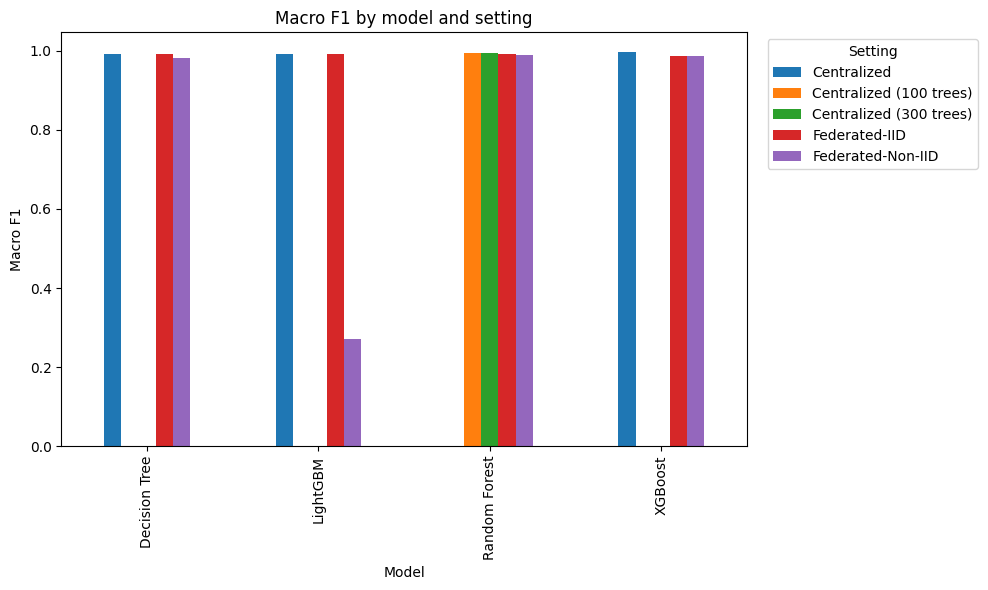

In [35]:
import matplotlib.pyplot as plt

pivot = results_df.pivot_table(index="Model", columns="Setting", values="Macro F1")

setting_order = [s for s in [
    "Centralized", "Centralized (100 trees)", "Centralized (300 trees)",
    "Federated-IID", "Federated-Non-IID"
] if s in pivot.columns]
pivot = pivot[setting_order]

ax = pivot.plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("Macro F1")
ax.set_title("Macro F1 by model and setting")
ax.legend(title="Setting", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()